In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Flights.csv')

In [3]:
df.head(10)

,Flight_ID,Customer_ID,Flight_Date,Flight_Number,Airline_Name,Origin_Airport,Destination_Airport,Distance_KM,Scheduled_Departure,Actual_Departure,Departure_Delay_Minutes,Scheduled_Arrival,Actual_Arrival,Arrival_Delay_Minutes,Aircraft_Type,Ticket_Price,Fuel_Cost,Weather_Condition,Flight_Status,Seat_Occupancy
0,1,117792,2023-12-29,CO6098,Continental Express,FRA,JFK,12927,2023-12-29 08:30:00,2023-12-29 09:22:00,52.0,2023-12-29 23:42:00,2023-12-30 01:10:00,88,Airbus A350,2590.98,1061.33,NaN,Delayed,65
1,2,109046,2023-07-16,CO5052,Continental Express,DXB,LAX,12926,2023-07-16 05:22:00,2023-07-16 05:27:00,5.0,2023-07-16 20:34:00,2023-07-16 20:56:00,22,Boeing 737,2033.55,1056.32,Clear,On Time,93
2,3,74778,2023-09-16,GL2601,Global Airways,YYZ,CDG,7418,2023-09-16 23:54:00,2023-09-17 00:00:00,6.0,2023-09-17 08:37:00,2023-09-17 08:48:00,11,Airbus A350,629.74,328.42,NaN,On Time,61
3,4,68958,2023-08-05,CO3032,Continental Express,SIN,CDG,4748,2023-08-05 01:02:00,2023-08-05 01:02:00,0.0,2023-08-05 06:37:00,2023-08-05 06:40:00,3,Boeing 737,935.61,295.52,Clear,On Time,62
4,5,113810,22/09/2023,ST8527,STARJET,LAX,HND,11567,2023-09-22 20:47:00,2023-09-22 20:48:00,1.0,2023-09-23 10:23:00,2023-09-23 10:52:00,29,Airbus A380,1603.45,820.57,Clear,On Time,98
5,6,111450,14/05/2023,CO4023,Continental Express,SFO,FRA,1036,2023-05-14 15:14:00,2023-05-14 15:15:00,1.0,2023-05-14 16:27:00,2023-05-14 16:23:00,-4,Airbus A350,89.26,34.00,Clear,On Time,72
6,7,73327,2023-05-26,OC8889,Oceanic Flights,ORD,SYD,13739,2023-05-26 14:08:00,2023-05-26 14:08:00,0.0,2023-05-27 06:17:00,2023-05-27 06:25:00,8,Airbus A320,1043.57,868.27,Fog,On Time,54
7,8,71099,2023-01-11,ST6841,StarJet,BOM,HND,3108,2023-01-11 02:13:00,2023-01-11 02:18:00,5.0,2023-01-11 05:52:00,2023-01-11 06:03:00,11,Airbus A380,409.88,95.95,Clear,On Time,62
8,9,46236,2023-05-13,OC3091,Oceanic Flights,HND,YYZ,8836,2023-05-13 10:25:00,2023-05-13 10:49:00,24.0,2023-05-13 20:48:00,2023-05-13 21:04:00,16,Airbus A320,554.48,605.93,Clear,Delayed,60
9,10,38436,2023-08-05,GL5084,Global Airways,DXB,YYZ,7370,2023-08-05 11:46:00,2023-08-05 11:58:00,12.0,2023-08-05 20:26:00,2023-08-05 20:37:00,11,Airbus A350,831.77,281.88,Clear,On Time,40


In [4]:
df.columns = df.columns.str.lower().str.strip()

In [5]:
df.head(10)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy
0,1,117792,2023-12-29,CO6098,Continental Express,FRA,JFK,12927,2023-12-29 08:30:00,2023-12-29 09:22:00,52.0,2023-12-29 23:42:00,2023-12-30 01:10:00,88,Airbus A350,2590.98,1061.33,NaN,Delayed,65
1,2,109046,2023-07-16,CO5052,Continental Express,DXB,LAX,12926,2023-07-16 05:22:00,2023-07-16 05:27:00,5.0,2023-07-16 20:34:00,2023-07-16 20:56:00,22,Boeing 737,2033.55,1056.32,Clear,On Time,93
2,3,74778,2023-09-16,GL2601,Global Airways,YYZ,CDG,7418,2023-09-16 23:54:00,2023-09-17 00:00:00,6.0,2023-09-17 08:37:00,2023-09-17 08:48:00,11,Airbus A350,629.74,328.42,NaN,On Time,61
3,4,68958,2023-08-05,CO3032,Continental Express,SIN,CDG,4748,2023-08-05 01:02:00,2023-08-05 01:02:00,0.0,2023-08-05 06:37:00,2023-08-05 06:40:00,3,Boeing 737,935.61,295.52,Clear,On Time,62
4,5,113810,22/09/2023,ST8527,STARJET,LAX,HND,11567,2023-09-22 20:47:00,2023-09-22 20:48:00,1.0,2023-09-23 10:23:00,2023-09-23 10:52:00,29,Airbus A380,1603.45,820.57,Clear,On Time,98
5,6,111450,14/05/2023,CO4023,Continental Express,SFO,FRA,1036,2023-05-14 15:14:00,2023-05-14 15:15:00,1.0,2023-05-14 16:27:00,2023-05-14 16:23:00,-4,Airbus A350,89.26,34.00,Clear,On Time,72
6,7,73327,2023-05-26,OC8889,Oceanic Flights,ORD,SYD,13739,2023-05-26 14:08:00,2023-05-26 14:08:00,0.0,2023-05-27 06:17:00,2023-05-27 06:25:00,8,Airbus A320,1043.57,868.27,Fog,On Time,54
7,8,71099,2023-01-11,ST6841,StarJet,BOM,HND,3108,2023-01-11 02:13:00,2023-01-11 02:18:00,5.0,2023-01-11 05:52:00,2023-01-11 06:03:00,11,Airbus A380,409.88,95.95,Clear,On Time,62
8,9,46236,2023-05-13,OC3091,Oceanic Flights,HND,YYZ,8836,2023-05-13 10:25:00,2023-05-13 10:49:00,24.0,2023-05-13 20:48:00,2023-05-13 21:04:00,16,Airbus A320,554.48,605.93,Clear,Delayed,60
9,10,38436,2023-08-05,GL5084,Global Airways,DXB,YYZ,7370,2023-08-05 11:46:00,2023-08-05 11:58:00,12.0,2023-08-05 20:26:00,2023-08-05 20:37:00,11,Airbus A350,831.77,281.88,Clear,On Time,40


In [6]:
df['flight_id'].duplicated().sum()

np.int64(4000)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.head(5)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy
0,1,117792,2023-12-29,CO6098,Continental Express,FRA,JFK,12927,2023-12-29 08:30:00,2023-12-29 09:22:00,52.0,2023-12-29 23:42:00,2023-12-30 01:10:00,88,Airbus A350,2590.98,1061.33,NaN,Delayed,65
1,2,109046,2023-07-16,CO5052,Continental Express,DXB,LAX,12926,2023-07-16 05:22:00,2023-07-16 05:27:00,5.0,2023-07-16 20:34:00,2023-07-16 20:56:00,22,Boeing 737,2033.55,1056.32,Clear,On Time,93
2,3,74778,2023-09-16,GL2601,Global Airways,YYZ,CDG,7418,2023-09-16 23:54:00,2023-09-17 00:00:00,6.0,2023-09-17 08:37:00,2023-09-17 08:48:00,11,Airbus A350,629.74,328.42,NaN,On Time,61
3,4,68958,2023-08-05,CO3032,Continental Express,SIN,CDG,4748,2023-08-05 01:02:00,2023-08-05 01:02:00,0.0,2023-08-05 06:37:00,2023-08-05 06:40:00,3,Boeing 737,935.61,295.52,Clear,On Time,62
4,5,113810,22/09/2023,ST8527,STARJET,LAX,HND,11567,2023-09-22 20:47:00,2023-09-22 20:48:00,1.0,2023-09-23 10:23:00,2023-09-23 10:52:00,29,Airbus A380,1603.45,820.57,Clear,On Time,98


In [9]:
df.nunique()

flight_id                  150000
customer_id                 85685
flight_date                  1095
flight_number               47107
airline_name                   20
origin_airport                 13
destination_airport            13
distance_km                 13701
scheduled_departure        130517
actual_departure           128344
departure_delay_minutes       242
scheduled_arrival          130337
actual_arrival             130402
arrival_delay_minutes         280
aircraft_type                   6
ticket_price               112471
fuel_cost                   76753
weather_condition               5
flight_status                   5
seat_occupancy                 61
dtype: int64

In [10]:
df['airline_name'].unique()

<StringArray>
[  'Continental Express',        'Global Airways',               'STARJET',
       'Oceanic Flights',               'StarJet',      'SkyHigh Airlines',
   'CONTINENTAL EXPRESS',      'SKYHIGH AIRLINES', '  Continental Express',
             '  StarJet',       'OCEANIC FLIGHTS',    '  SkyHigh Airlines',
     '  Oceanic Flights',      '  Global Airways', '  CONTINENTAL EXPRESS',
        'GLOBAL AIRWAYS',    '  SKYHIGH AIRLINES',     '  OCEANIC FLIGHTS',
      '  GLOBAL AIRWAYS',             '  STARJET']
Length: 20, dtype: str

In [11]:
df['airline_name']= df['airline_name'].str.strip().str.title()

In [12]:
df['airline_name'].unique()

<StringArray>
['Continental Express',      'Global Airways',             'Starjet',
     'Oceanic Flights',    'Skyhigh Airlines']
Length: 5, dtype: str

In [13]:
df.nunique()

flight_id                  150000
customer_id                 85685
flight_date                  1095
flight_number               47107
airline_name                    5
origin_airport                 13
destination_airport            13
distance_km                 13701
scheduled_departure        130517
actual_departure           128344
departure_delay_minutes       242
scheduled_arrival          130337
actual_arrival             130402
arrival_delay_minutes         280
aircraft_type                   6
ticket_price               112471
fuel_cost                   76753
weather_condition               5
flight_status                   5
seat_occupancy                 61
dtype: int64

In [14]:
df['origin_airport']= df['origin_airport'].str.strip().str.title()
df['destination_airport']= df['destination_airport'].str.strip().str.title()
df['aircraft_type']= df['aircraft_type'].str.strip().str.title()
df['weather_condition']= df['weather_condition'].str.strip().str.title()
df['flight_status']= df['flight_status'].str.strip().str.title()

In [15]:
df.nunique()

flight_id                  150000
customer_id                 85685
flight_date                  1095
flight_number               47107
airline_name                    5
origin_airport                 13
destination_airport            13
distance_km                 13701
scheduled_departure        130517
actual_departure           128344
departure_delay_minutes       242
scheduled_arrival          130337
actual_arrival             130402
arrival_delay_minutes         280
aircraft_type                   6
ticket_price               112471
fuel_cost                   76753
weather_condition               5
flight_status                   3
seat_occupancy                 61
dtype: int64

In [16]:
df['flight_status'].unique()

<StringArray>
['Delayed', 'On Time', 'Cancelled']
Length: 3, dtype: str

In [17]:
df.isnull().sum()

flight_id                      0
customer_id                    0
flight_date                    0
flight_number                  0
airline_name                   0
origin_airport                 0
destination_airport            0
distance_km                    0
scheduled_departure            0
actual_departure            3000
departure_delay_minutes    12000
scheduled_arrival              0
actual_arrival                 0
arrival_delay_minutes          0
aircraft_type                  0
ticket_price                   0
fuel_cost                      0
weather_condition           8000
flight_status                  0
seat_occupancy                 0
dtype: int64

In [18]:
actual_departure = df['actual_departure'].isnull().mean()*100
departure_delay_minutes = df['departure_delay_minutes'].isnull().mean()*100
weather_condition = df['weather_condition'].isnull().mean()*100

print(actual_departure)
print(departure_delay_minutes)
print(weather_condition)

2.0
8.0
5.333333333333334


In [19]:
df.dropna(subset=['actual_departure'], inplace=True)

In [20]:
df['departure_delay_minutes'] = df['departure_delay_minutes'].fillna(0)

In [21]:
df['weather_condition'] = df['weather_condition'].fillna('Unknown')

In [22]:
df.isnull().sum()

flight_id                  0
customer_id                0
flight_date                0
flight_number              0
airline_name               0
origin_airport             0
destination_airport        0
distance_km                0
scheduled_departure        0
actual_departure           0
departure_delay_minutes    0
scheduled_arrival          0
actual_arrival             0
arrival_delay_minutes      0
aircraft_type              0
ticket_price               0
fuel_cost                  0
weather_condition          0
flight_status              0
seat_occupancy             0
dtype: int64

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 147000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   flight_id                147000 non-null  int64  
 1   customer_id              147000 non-null  int64  
 2   flight_date              147000 non-null  str    
 3   flight_number            147000 non-null  str    
 4   airline_name             147000 non-null  str    
 5   origin_airport           147000 non-null  str    
 6   destination_airport      147000 non-null  str    
 7   distance_km              147000 non-null  int64  
 8   scheduled_departure      147000 non-null  str    
 9   actual_departure         147000 non-null  str    
 10  departure_delay_minutes  147000 non-null  float64
 11  scheduled_arrival        147000 non-null  str    
 12  actual_arrival           147000 non-null  str    
 13  arrival_delay_minutes    147000 non-null  int64  
 14  aircraft_type       

In [24]:
df['flight_date'] = pd.to_datetime(df['flight_date'], errors='coerce')

In [25]:
df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'], errors='coerce')

In [26]:
df['actual_departure'] = pd.to_datetime(df['actual_departure'], errors='coerce')

In [27]:
df['scheduled_arrival'] = pd.to_datetime(df['scheduled_arrival'], errors='coerce')

In [28]:
df['actual_arrival'] = pd.to_datetime(df['actual_arrival'], errors='coerce')

In [29]:
df['departure_delay_minutes'] = df['departure_delay_minutes'].astype(int)

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 147000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   flight_id                147000 non-null  int64         
 1   customer_id              147000 non-null  int64         
 2   flight_date              125219 non-null  datetime64[us]
 3   flight_number            147000 non-null  str           
 4   airline_name             147000 non-null  str           
 5   origin_airport           147000 non-null  str           
 6   destination_airport      147000 non-null  str           
 7   distance_km              147000 non-null  int64         
 8   scheduled_departure      147000 non-null  datetime64[us]
 9   actual_departure         147000 non-null  datetime64[us]
 10  departure_delay_minutes  147000 non-null  int64         
 11  scheduled_arrival        147000 non-null  datetime64[us]
 12  actual_arrival           147000 

In [31]:
df.tail(10)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy
149990,149991,96919,2023-11-24,SK7986,Skyhigh Airlines,Syd,Sfo,13084,2023-11-24 09:41:00,2023-11-24 10:05:00,24,2023-11-25 01:04:00,2023-11-25 01:54:00,50,Boeing 787,1805.62,1012.77,Storm,Delayed,78
149991,149992,51807,2023-06-01,CO2218,Continental Express,Cdg,Ord,606,2023-06-01 04:52:00,2023-06-01 04:57:00,5,2023-06-01 05:34:00,2023-06-01 05:22:00,-12,Airbus A320,148.36,39.47,Unknown,On Time,48
149992,149993,10083,NaT,CO8811,Continental Express,Fra,Hnd,9070,2023-09-06 05:27:00,2023-09-06 05:44:00,17,2023-09-06 16:07:00,2023-09-06 16:35:00,28,Airbus A380,1306.67,521.07,Snow,Delayed,85
149993,149994,25128,2023-07-12,ST1795,Starjet,Bom,Ord,8940,2023-07-12 21:26:00,2023-07-12 21:31:00,5,2023-07-13 07:57:00,2023-07-13 07:49:00,-8,Boeing 787,1629.68,608.55,Clear,On Time,61
149994,149995,57660,2023-04-17,OC6787,Oceanic Flights,Sin,Hnd,4912,2023-04-17 08:19:00,2023-04-17 08:24:00,5,2023-04-17 14:05:00,2023-04-17 14:22:00,17,Airbus A320,1208.93,253.50,Clear,On Time,53
149995,149996,69737,2023-07-20,GL273,Global Airways,Hnd,Lhr,11058,2023-07-20 14:53:00,2023-07-20 15:03:00,10,2023-07-21 03:53:00,2023-07-21 04:22:00,29,Airbus A380,2164.19,573.51,Clear,On Time,62
149996,149997,76402,NaT,CO3471,Continental Express,Dxb,Jfk,6070,2023-10-22 21:00:00,2023-10-22 21:52:00,52,2023-10-23 04:08:00,2023-10-23 04:58:00,50,Boeing 787,903.92,395.45,Clear,Delayed,62
149997,149998,33584,2023-01-05,ST5331,Starjet,Yyz,Syd,4443,2023-01-05 00:58:00,2023-01-05 00:59:00,1,2023-01-05 06:11:00,2023-01-05 06:23:00,12,Airbus A380,698.75,222.46,Clear,On Time,47
149998,149999,34346,2023-04-15,OC5704,Oceanic Flights,Hnd,Syd,2916,2023-04-15 02:10:00,2023-04-15 02:25:00,15,2023-04-15 05:35:00,2023-04-15 06:18:00,43,Boeing 737,576.87,193.76,Fog,On Time,45
149999,150000,63746,2023-04-06,OC4793,Oceanic Flights,Dxb,Cdg,12258,2023-04-06 04:09:00,2023-04-06 04:23:00,14,2023-04-06 18:34:00,2023-04-06 18:48:00,14,Boeing 777,1180.30,615.92,Fog,On Time,91


In [32]:
df.describe()

,flight_id,customer_id,flight_date,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,ticket_price,fuel_cost,seat_occupancy
count,147000.000000,147000.000000,125219,147000.000000,147000,147000,147000.000000,147000,147000,147000.000000,147000.000000,147000.000000,147000.000000
mean,75009.472054,60043.271884,2023-07-02 01:01:27.312628,7148.104823,2023-07-02 10:38:08.024897,2023-07-02 10:50:52.920000,11.708871,2023-07-02 19:02:23.659591,2023-07-02 19:24:36.912244,22.220878,1108.321795,428.749603,69.934680
min,1.000000,1.000000,2023-01-01 00:00:00,-800.000000,2023-01-01 00:05:00,2023-01-01 00:14:00,0.000000,2023-01-01 01:40:00,2023-01-01 01:39:00,-20.000000,-150.000000,9.190000,40.000000
25%,37486.750000,29946.500000,2023-04-01 00:00:00,3743.000000,2023-04-01 19:18:30,2023-04-01 19:36:15,2.000000,2023-04-02 03:36:45,2023-04-02 04:07:00,4.000000,497.475000,204.330000,55.000000
50%,75008.500000,60014.500000,2023-07-02 00:00:00,7156.500000,2023-07-02 13:48:30,2023-07-02 13:58:00,6.000000,2023-07-02 22:29:00,2023-07-02 22:59:00,20.000000,956.970000,389.860000,70.000000
75%,112525.250000,90096.000000,2023-10-02 00:00:00,10569.000000,2023-10-01 23:48:30,2023-10-01 23:56:45,14.000000,2023-10-02 08:30:30,2023-10-02 08:46:45,36.000000,1597.132500,612.522500,85.000000
max,150000.000000,999992.000000,2023-12-31 00:00:00,13999.000000,2023-12-31 23:51:00,2024-01-01 01:42:00,364.000000,2024-01-01 14:39:00,2024-01-01 15:00:00,373.000000,3482.780000,1258.620000,100.000000
std,43317.541093,34873.977625,NaN,3950.588237,NaN,NaN,18.259732,NaN,NaN,25.517810,759.746468,275.627558,17.615462


In [33]:
df[df['distance_km'] < 0].head(10)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy
200,201,11354,2023-01-30,ST8659,Starjet,Lax,Jfk,-800,2023-01-30 09:22:00,2023-01-30 09:24:00,2,2023-01-30 18:24:00,2023-01-30 18:41:00,17,Airbus A350,1746.31,664.32,Clear,On Time,94
201,202,28514,NaT,SK1298,Skyhigh Airlines,Cdg,Dxb,-800,2023-05-24 18:24:00,2023-05-24 19:31:00,67,2023-05-24 19:11:00,2023-05-24 20:51:00,100,Airbus A380,114.46,56.88,Storm,Delayed,48
202,203,50090,NaT,GL1986,Global Airways,Dxb,Bom,-800,2023-06-20 22:23:00,2023-06-20 22:28:00,5,2023-06-21 13:44:00,2023-06-21 14:17:00,33,Boeing 737,2953.28,1000.22,Fog,On Time,69
203,204,50474,2023-05-16,ST9004,Starjet,Hnd,Lhr,-800,2023-05-16 09:58:00,2023-05-16 09:58:00,0,2023-05-16 21:10:00,2023-05-16 21:09:00,-1,Boeing 777,798.27,665.81,Clear,On Time,89
204,205,27070,2023-04-15,GL2376,Global Airways,Dxb,Lax,-800,2023-04-15 12:35:00,2023-04-15 12:36:00,1,2023-04-15 13:57:00,2023-04-15 14:10:00,13,Boeing 787,203.74,84.45,Unknown,On Time,100
205,206,97801,NaT,OC2385,Oceanic Flights,Syd,Lax,-800,2023-04-15 02:32:00,2023-04-15 02:35:00,3,2023-04-15 17:09:00,2023-04-15 17:40:00,31,Boeing 787,2007.20,395.34,Clear,On Time,59
206,207,64193,2023-10-10,OC8143,Oceanic Flights,Dxb,Syd,-800,2023-10-10 04:29:00,2023-10-10 04:52:00,23,2023-10-10 08:43:00,2023-10-10 08:51:00,8,Airbus A320,523.33,263.17,Rain,Delayed,93
208,209,47524,2023-11-19,CO4107,Continental Express,Sfo,Hnd,-800,2023-11-19 05:08:00,2023-11-19 05:08:00,0,2023-11-19 11:54:00,2023-11-19 12:24:00,30,Boeing 737,948.89,376.74,Clear,Delayed,54
209,210,56269,2023-12-08,OC4592,Oceanic Flights,Lax,Cdg,-800,2023-12-08 17:21:00,2023-12-08 17:23:00,2,2023-12-09 04:11:00,2023-12-09 04:35:00,24,Boeing 777,1359.76,780.93,Clear,On Time,61
210,211,111142,2023-11-22,GL8444,Global Airways,Lhr,Lax,-800,2023-11-22 03:12:00,2023-11-22 03:34:00,22,2023-11-22 04:16:00,2023-11-22 05:12:00,56,Airbus A350,108.98,63.77,Clear,Delayed,95


In [34]:
df[df['ticket_price'] < 0].head(10)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy
800,801,90390,2023-01-01,GL6232,Global Airways,Jfk,Ord,13122,2023-01-01 23:25:00,2023-01-01 23:40:00,15,2023-01-02 14:51:00,2023-01-02 14:56:00,5,Boeing 787,-150.0,634.61,Clear,On Time,69
801,802,92348,NaT,CO5869,Continental Express,Sin,Yyz,800,2023-07-27 14:09:00,2023-07-27 14:09:00,0,2023-07-27 15:05:00,2023-07-27 15:38:00,33,Airbus A380,-150.0,52.58,Clear,On Time,97
802,803,66927,2023-12-29,GL677,Global Airways,Lhr,Jfk,12660,2023-12-29 07:33:00,2023-12-29 07:43:00,10,2023-12-29 22:26:00,2023-12-29 22:54:00,28,Airbus A320,-150.0,671.77,Clear,On Time,62
803,804,110038,2023-12-08,CO1701,Continental Express,Sfo,Bom,6367,2023-12-08 01:49:00,2023-12-08 01:59:00,0,2023-12-08 09:18:00,2023-12-08 09:24:00,6,Boeing 737,-150.0,264.97,Rain,On Time,99
804,805,88878,NaT,SK2248,Skyhigh Airlines,Lax,Lhr,1282,2023-10-14 14:26:00,2023-10-14 14:43:00,17,2023-10-14 15:56:00,2023-10-14 16:25:00,29,Boeing 737,-150.0,111.58,Clear,Delayed,53
805,806,101452,NaT,SK7665,Skyhigh Airlines,Lax,Jfk,13042,2023-04-21 16:26:00,2023-04-21 16:30:00,4,2023-04-22 07:46:00,2023-04-22 07:40:00,-6,Boeing 787,-150.0,653.74,Unknown,On Time,55
806,807,116913,2023-05-22,OC9053,Oceanic Flights,Lhr,Lax,11401,2023-05-22 04:02:00,2023-05-22 04:23:00,21,2023-05-22 17:26:00,2023-05-22 17:52:00,26,Boeing 777,-150.0,980.09,Clear,Delayed,74
807,808,84474,NaT,SK8183,Skyhigh Airlines,Lhr,Bom,3354,2023-12-10 17:42:00,2023-12-10 17:47:00,5,2023-12-10 21:38:00,2023-12-10 21:49:00,11,Boeing 737,-150.0,281.02,Clear,On Time,92
808,809,14910,2023-10-26,CO1421,Continental Express,Yyz,Jfk,2249,2023-10-26 13:47:00,2023-10-26 14:03:00,16,2023-10-26 16:25:00,2023-10-26 16:53:00,28,Airbus A350,-150.0,172.72,Storm,Delayed,66
809,810,58094,2023-04-17,ST3702,Starjet,Bom,Fra,839,2023-04-17 08:28:00,2023-04-17 08:33:00,0,2023-04-17 09:27:00,2023-04-17 09:59:00,32,Airbus A380,-150.0,51.34,Rain,On Time,90


In [35]:
df.loc[df['distance_km'] <0, 'distance_km'] = np.nan
df.loc[df['ticket_price'] <0, 'ticket_price'] = np.nan

In [36]:
df['distance_km'] = df['distance_km'].fillna(df['distance_km'].median())
df['ticket_price'] = df['ticket_price'].fillna(df['ticket_price'].median())

In [37]:
df.isnull().sum()

flight_id                      0
customer_id                    0
flight_date                21781
flight_number                  0
airline_name                   0
origin_airport                 0
destination_airport            0
distance_km                    0
scheduled_departure            0
actual_departure               0
departure_delay_minutes        0
scheduled_arrival              0
actual_arrival                 0
arrival_delay_minutes          0
aircraft_type                  0
ticket_price                   0
fuel_cost                      0
weather_condition              0
flight_status                  0
seat_occupancy                 0
dtype: int64

In [38]:
df.tail(10)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy
149990,149991,96919,2023-11-24,SK7986,Skyhigh Airlines,Syd,Sfo,13084.0,2023-11-24 09:41:00,2023-11-24 10:05:00,24,2023-11-25 01:04:00,2023-11-25 01:54:00,50,Boeing 787,1805.62,1012.77,Storm,Delayed,78
149991,149992,51807,2023-06-01,CO2218,Continental Express,Cdg,Ord,606.0,2023-06-01 04:52:00,2023-06-01 04:57:00,5,2023-06-01 05:34:00,2023-06-01 05:22:00,-12,Airbus A320,148.36,39.47,Unknown,On Time,48
149992,149993,10083,NaT,CO8811,Continental Express,Fra,Hnd,9070.0,2023-09-06 05:27:00,2023-09-06 05:44:00,17,2023-09-06 16:07:00,2023-09-06 16:35:00,28,Airbus A380,1306.67,521.07,Snow,Delayed,85
149993,149994,25128,2023-07-12,ST1795,Starjet,Bom,Ord,8940.0,2023-07-12 21:26:00,2023-07-12 21:31:00,5,2023-07-13 07:57:00,2023-07-13 07:49:00,-8,Boeing 787,1629.68,608.55,Clear,On Time,61
149994,149995,57660,2023-04-17,OC6787,Oceanic Flights,Sin,Hnd,4912.0,2023-04-17 08:19:00,2023-04-17 08:24:00,5,2023-04-17 14:05:00,2023-04-17 14:22:00,17,Airbus A320,1208.93,253.50,Clear,On Time,53
149995,149996,69737,2023-07-20,GL273,Global Airways,Hnd,Lhr,11058.0,2023-07-20 14:53:00,2023-07-20 15:03:00,10,2023-07-21 03:53:00,2023-07-21 04:22:00,29,Airbus A380,2164.19,573.51,Clear,On Time,62
149996,149997,76402,NaT,CO3471,Continental Express,Dxb,Jfk,6070.0,2023-10-22 21:00:00,2023-10-22 21:52:00,52,2023-10-23 04:08:00,2023-10-23 04:58:00,50,Boeing 787,903.92,395.45,Clear,Delayed,62
149997,149998,33584,2023-01-05,ST5331,Starjet,Yyz,Syd,4443.0,2023-01-05 00:58:00,2023-01-05 00:59:00,1,2023-01-05 06:11:00,2023-01-05 06:23:00,12,Airbus A380,698.75,222.46,Clear,On Time,47
149998,149999,34346,2023-04-15,OC5704,Oceanic Flights,Hnd,Syd,2916.0,2023-04-15 02:10:00,2023-04-15 02:25:00,15,2023-04-15 05:35:00,2023-04-15 06:18:00,43,Boeing 737,576.87,193.76,Fog,On Time,45
149999,150000,63746,2023-04-06,OC4793,Oceanic Flights,Dxb,Cdg,12258.0,2023-04-06 04:09:00,2023-04-06 04:23:00,14,2023-04-06 18:34:00,2023-04-06 18:48:00,14,Boeing 777,1180.30,615.92,Fog,On Time,91


In [39]:
df['flight_date']= df['flight_date'].fillna(df['scheduled_departure'].dt.date)

In [40]:
df.tail(10)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy
149990,149991,96919,2023-11-24,SK7986,Skyhigh Airlines,Syd,Sfo,13084.0,2023-11-24 09:41:00,2023-11-24 10:05:00,24,2023-11-25 01:04:00,2023-11-25 01:54:00,50,Boeing 787,1805.62,1012.77,Storm,Delayed,78
149991,149992,51807,2023-06-01,CO2218,Continental Express,Cdg,Ord,606.0,2023-06-01 04:52:00,2023-06-01 04:57:00,5,2023-06-01 05:34:00,2023-06-01 05:22:00,-12,Airbus A320,148.36,39.47,Unknown,On Time,48
149992,149993,10083,2023-09-06,CO8811,Continental Express,Fra,Hnd,9070.0,2023-09-06 05:27:00,2023-09-06 05:44:00,17,2023-09-06 16:07:00,2023-09-06 16:35:00,28,Airbus A380,1306.67,521.07,Snow,Delayed,85
149993,149994,25128,2023-07-12,ST1795,Starjet,Bom,Ord,8940.0,2023-07-12 21:26:00,2023-07-12 21:31:00,5,2023-07-13 07:57:00,2023-07-13 07:49:00,-8,Boeing 787,1629.68,608.55,Clear,On Time,61
149994,149995,57660,2023-04-17,OC6787,Oceanic Flights,Sin,Hnd,4912.0,2023-04-17 08:19:00,2023-04-17 08:24:00,5,2023-04-17 14:05:00,2023-04-17 14:22:00,17,Airbus A320,1208.93,253.50,Clear,On Time,53
149995,149996,69737,2023-07-20,GL273,Global Airways,Hnd,Lhr,11058.0,2023-07-20 14:53:00,2023-07-20 15:03:00,10,2023-07-21 03:53:00,2023-07-21 04:22:00,29,Airbus A380,2164.19,573.51,Clear,On Time,62
149996,149997,76402,2023-10-22,CO3471,Continental Express,Dxb,Jfk,6070.0,2023-10-22 21:00:00,2023-10-22 21:52:00,52,2023-10-23 04:08:00,2023-10-23 04:58:00,50,Boeing 787,903.92,395.45,Clear,Delayed,62
149997,149998,33584,2023-01-05,ST5331,Starjet,Yyz,Syd,4443.0,2023-01-05 00:58:00,2023-01-05 00:59:00,1,2023-01-05 06:11:00,2023-01-05 06:23:00,12,Airbus A380,698.75,222.46,Clear,On Time,47
149998,149999,34346,2023-04-15,OC5704,Oceanic Flights,Hnd,Syd,2916.0,2023-04-15 02:10:00,2023-04-15 02:25:00,15,2023-04-15 05:35:00,2023-04-15 06:18:00,43,Boeing 737,576.87,193.76,Fog,On Time,45
149999,150000,63746,2023-04-06,OC4793,Oceanic Flights,Dxb,Cdg,12258.0,2023-04-06 04:09:00,2023-04-06 04:23:00,14,2023-04-06 18:34:00,2023-04-06 18:48:00,14,Boeing 777,1180.30,615.92,Fog,On Time,91


In [41]:
df.isnull().sum()

flight_id                  0
customer_id                0
flight_date                0
flight_number              0
airline_name               0
origin_airport             0
destination_airport        0
distance_km                0
scheduled_departure        0
actual_departure           0
departure_delay_minutes    0
scheduled_arrival          0
actual_arrival             0
arrival_delay_minutes      0
aircraft_type              0
ticket_price               0
fuel_cost                  0
weather_condition          0
flight_status              0
seat_occupancy             0
dtype: int64

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 147000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   flight_id                147000 non-null  int64         
 1   customer_id              147000 non-null  int64         
 2   flight_date              147000 non-null  datetime64[us]
 3   flight_number            147000 non-null  str           
 4   airline_name             147000 non-null  str           
 5   origin_airport           147000 non-null  str           
 6   destination_airport      147000 non-null  str           
 7   distance_km              147000 non-null  float64       
 8   scheduled_departure      147000 non-null  datetime64[us]
 9   actual_departure         147000 non-null  datetime64[us]
 10  departure_delay_minutes  147000 non-null  int64         
 11  scheduled_arrival        147000 non-null  datetime64[us]
 12  actual_arrival           147000 

In [44]:
df.describe()

,flight_id,customer_id,flight_date,distance_km,scheduled_departure,actual_departure,departure_delay_minutes,scheduled_arrival,actual_arrival,arrival_delay_minutes,ticket_price,fuel_cost,seat_occupancy
count,147000.000000,147000.000000,147000,147000.000000,147000,147000,147000.000000,147000,147000,147000.000000,147000.000000,147000.000000,147000.000000
mean,75009.472054,60043.271884,2023-07-01 22:38:07.542857,7150.757823,2023-07-02 10:38:08.024897,2023-07-02 10:50:52.920000,11.708871,2023-07-02 19:02:23.659591,2023-07-02 19:24:36.912244,22.220878,1108.705929,428.749603,69.934680
min,1.000000,1.000000,2023-01-01 00:00:00,300.000000,2023-01-01 00:05:00,2023-01-01 00:14:00,0.000000,2023-01-01 01:40:00,2023-01-01 01:39:00,-20.000000,18.200000,9.190000,40.000000
25%,37486.750000,29946.500000,2023-04-01 00:00:00,3748.000000,2023-04-01 19:18:30,2023-04-01 19:36:15,2.000000,2023-04-02 03:36:45,2023-04-02 04:07:00,4.000000,498.197500,204.330000,55.000000
50%,75008.500000,60014.500000,2023-07-02 00:00:00,7159.000000,2023-07-02 13:48:30,2023-07-02 13:58:00,6.000000,2023-07-02 22:29:00,2023-07-02 22:59:00,20.000000,957.210000,389.860000,70.000000
75%,112525.250000,90096.000000,2023-10-01 00:00:00,10569.000000,2023-10-01 23:48:30,2023-10-01 23:56:45,14.000000,2023-10-02 08:30:30,2023-10-02 08:46:45,36.000000,1597.132500,612.522500,85.000000
max,150000.000000,999992.000000,2023-12-31 00:00:00,13999.000000,2023-12-31 23:51:00,2024-01-01 01:42:00,364.000000,2024-01-01 14:39:00,2024-01-01 15:00:00,373.000000,3482.780000,1258.620000,100.000000
std,43317.541093,34873.977625,NaN,3947.921329,NaN,NaN,18.259732,NaN,NaN,25.517810,759.389974,275.627558,17.615462


In [45]:
df.to_csv('cleaned_flights_csv', index=False)

In [46]:
date_cols=['flight_date', 'scheduled_departure', 'actual_departure', 'scheduled_arrival', 'actual_arrival']
df=pd.read_csv('cleaned_flights_csv', parse_dates=date_cols)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147000 entries, 0 to 146999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   flight_id                147000 non-null  int64         
 1   customer_id              147000 non-null  int64         
 2   flight_date              147000 non-null  datetime64[us]
 3   flight_number            147000 non-null  str           
 4   airline_name             147000 non-null  str           
 5   origin_airport           147000 non-null  str           
 6   destination_airport      147000 non-null  str           
 7   distance_km              147000 non-null  float64       
 8   scheduled_departure      147000 non-null  datetime64[us]
 9   actual_departure         147000 non-null  datetime64[us]
 10  departure_delay_minutes  147000 non-null  int64         
 11  scheduled_arrival        147000 non-null  datetime64[us]
 12  actual_arrival           14

In [48]:
df['flight_month'] = df['flight_date'].dt.strftime('%b')

In [49]:
df.head(5)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,...,scheduled_arrival,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy,flight_month
0,1,117792,2023-12-29,CO6098,Continental Express,Fra,Jfk,12927.0,2023-12-29 08:30:00,2023-12-29 09:22:00,...,2023-12-29 23:42:00,2023-12-30 01:10:00,88,Airbus A350,2590.98,1061.33,Unknown,Delayed,65,Dec
1,2,109046,2023-07-16,CO5052,Continental Express,Dxb,Lax,12926.0,2023-07-16 05:22:00,2023-07-16 05:27:00,...,2023-07-16 20:34:00,2023-07-16 20:56:00,22,Boeing 737,2033.55,1056.32,Clear,On Time,93,Jul
2,3,74778,2023-09-16,GL2601,Global Airways,Yyz,Cdg,7418.0,2023-09-16 23:54:00,2023-09-17 00:00:00,...,2023-09-17 08:37:00,2023-09-17 08:48:00,11,Airbus A350,629.74,328.42,Unknown,On Time,61,Sep
3,4,68958,2023-08-05,CO3032,Continental Express,Sin,Cdg,4748.0,2023-08-05 01:02:00,2023-08-05 01:02:00,...,2023-08-05 06:37:00,2023-08-05 06:40:00,3,Boeing 737,935.61,295.52,Clear,On Time,62,Aug
4,5,113810,2023-09-22,ST8527,Starjet,Lax,Hnd,11567.0,2023-09-22 20:47:00,2023-09-22 20:48:00,...,2023-09-23 10:23:00,2023-09-23 10:52:00,29,Airbus A380,1603.45,820.57,Clear,On Time,98,Sep


In [50]:
df['delay_category']= np.select(
    [
        df['arrival_delay_minutes'] <=0,
        (df['arrival_delay_minutes'] >=1) & (df['arrival_delay_minutes'] <=30),
        df['arrival_delay_minutes'] >30
    ],
    [
        "On Time",
        "Slight Delay",
        "Significant Delay"
    ],
    default="Unknown"
)

In [51]:
df.head(5)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,...,actual_arrival,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy,flight_month,delay_category
0,1,117792,2023-12-29,CO6098,Continental Express,Fra,Jfk,12927.0,2023-12-29 08:30:00,2023-12-29 09:22:00,...,2023-12-30 01:10:00,88,Airbus A350,2590.98,1061.33,Unknown,Delayed,65,Dec,Significant Delay
1,2,109046,2023-07-16,CO5052,Continental Express,Dxb,Lax,12926.0,2023-07-16 05:22:00,2023-07-16 05:27:00,...,2023-07-16 20:56:00,22,Boeing 737,2033.55,1056.32,Clear,On Time,93,Jul,Slight Delay
2,3,74778,2023-09-16,GL2601,Global Airways,Yyz,Cdg,7418.0,2023-09-16 23:54:00,2023-09-17 00:00:00,...,2023-09-17 08:48:00,11,Airbus A350,629.74,328.42,Unknown,On Time,61,Sep,Slight Delay
3,4,68958,2023-08-05,CO3032,Continental Express,Sin,Cdg,4748.0,2023-08-05 01:02:00,2023-08-05 01:02:00,...,2023-08-05 06:40:00,3,Boeing 737,935.61,295.52,Clear,On Time,62,Aug,Slight Delay
4,5,113810,2023-09-22,ST8527,Starjet,Lax,Hnd,11567.0,2023-09-22 20:47:00,2023-09-22 20:48:00,...,2023-09-23 10:52:00,29,Airbus A380,1603.45,820.57,Clear,On Time,98,Sep,Slight Delay


In [52]:
df['distance_category'] = np.select(
    [
        df['distance_km'] <=1000,
        (df['distance_km'] > 1000) & (df['distance_km'] < 5000),
        df['distance_km'] > 5000
    ],
    [
        "Short Distance",
        "Medium Distance",
        "Long Distance"
    ],
    default="Unknwon"
)

In [53]:
df.head(5)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,...,arrival_delay_minutes,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy,flight_month,delay_category,distance_category
0,1,117792,2023-12-29,CO6098,Continental Express,Fra,Jfk,12927.0,2023-12-29 08:30:00,2023-12-29 09:22:00,...,88,Airbus A350,2590.98,1061.33,Unknown,Delayed,65,Dec,Significant Delay,Long Distance
1,2,109046,2023-07-16,CO5052,Continental Express,Dxb,Lax,12926.0,2023-07-16 05:22:00,2023-07-16 05:27:00,...,22,Boeing 737,2033.55,1056.32,Clear,On Time,93,Jul,Slight Delay,Long Distance
2,3,74778,2023-09-16,GL2601,Global Airways,Yyz,Cdg,7418.0,2023-09-16 23:54:00,2023-09-17 00:00:00,...,11,Airbus A350,629.74,328.42,Unknown,On Time,61,Sep,Slight Delay,Long Distance
3,4,68958,2023-08-05,CO3032,Continental Express,Sin,Cdg,4748.0,2023-08-05 01:02:00,2023-08-05 01:02:00,...,3,Boeing 737,935.61,295.52,Clear,On Time,62,Aug,Slight Delay,Medium Distance
4,5,113810,2023-09-22,ST8527,Starjet,Lax,Hnd,11567.0,2023-09-22 20:47:00,2023-09-22 20:48:00,...,29,Airbus A380,1603.45,820.57,Clear,On Time,98,Sep,Slight Delay,Long Distance


In [54]:
df['total_revenue'] = df['ticket_price'] * df['seat_occupancy'] 

In [55]:
df.head(5)

,flight_id,customer_id,flight_date,flight_number,airline_name,origin_airport,destination_airport,distance_km,scheduled_departure,actual_departure,...,aircraft_type,ticket_price,fuel_cost,weather_condition,flight_status,seat_occupancy,flight_month,delay_category,distance_category,total_revenue
0,1,117792,2023-12-29,CO6098,Continental Express,Fra,Jfk,12927.0,2023-12-29 08:30:00,2023-12-29 09:22:00,...,Airbus A350,2590.98,1061.33,Unknown,Delayed,65,Dec,Significant Delay,Long Distance,168413.70
1,2,109046,2023-07-16,CO5052,Continental Express,Dxb,Lax,12926.0,2023-07-16 05:22:00,2023-07-16 05:27:00,...,Boeing 737,2033.55,1056.32,Clear,On Time,93,Jul,Slight Delay,Long Distance,189120.15
2,3,74778,2023-09-16,GL2601,Global Airways,Yyz,Cdg,7418.0,2023-09-16 23:54:00,2023-09-17 00:00:00,...,Airbus A350,629.74,328.42,Unknown,On Time,61,Sep,Slight Delay,Long Distance,38414.14
3,4,68958,2023-08-05,CO3032,Continental Express,Sin,Cdg,4748.0,2023-08-05 01:02:00,2023-08-05 01:02:00,...,Boeing 737,935.61,295.52,Clear,On Time,62,Aug,Slight Delay,Medium Distance,58007.82
4,5,113810,2023-09-22,ST8527,Starjet,Lax,Hnd,11567.0,2023-09-22 20:47:00,2023-09-22 20:48:00,...,Airbus A380,1603.45,820.57,Clear,On Time,98,Sep,Slight Delay,Long Distance,157138.10


C:\Users\abasa\AppData\Local\Temp\ipykernel_5376\2602039766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='arrival_delay_minutes', y='weather_condition', data=weather_delay, palette='viridis')


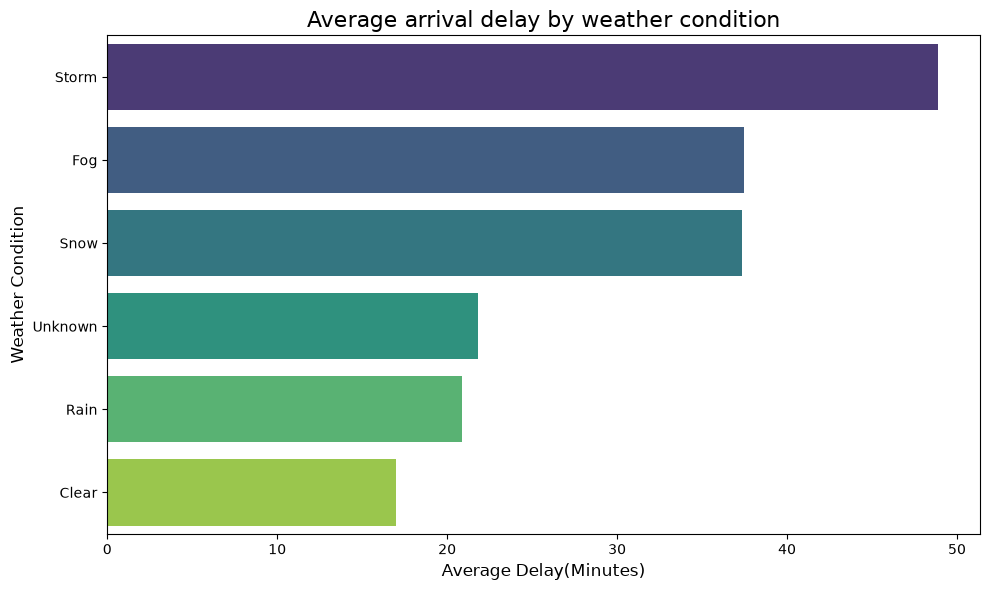

In [56]:
weather_delay= df.groupby('weather_condition')['arrival_delay_minutes'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='arrival_delay_minutes', y='weather_condition', data=weather_delay, palette='viridis')
plt.title('Average arrival delay by weather condition', fontsize=16)
plt.xlabel('Average Delay(Minutes)', fontsize=12)
plt.ylabel('Weather Condition', fontsize=12)
plt.tight_layout()
plt.show()

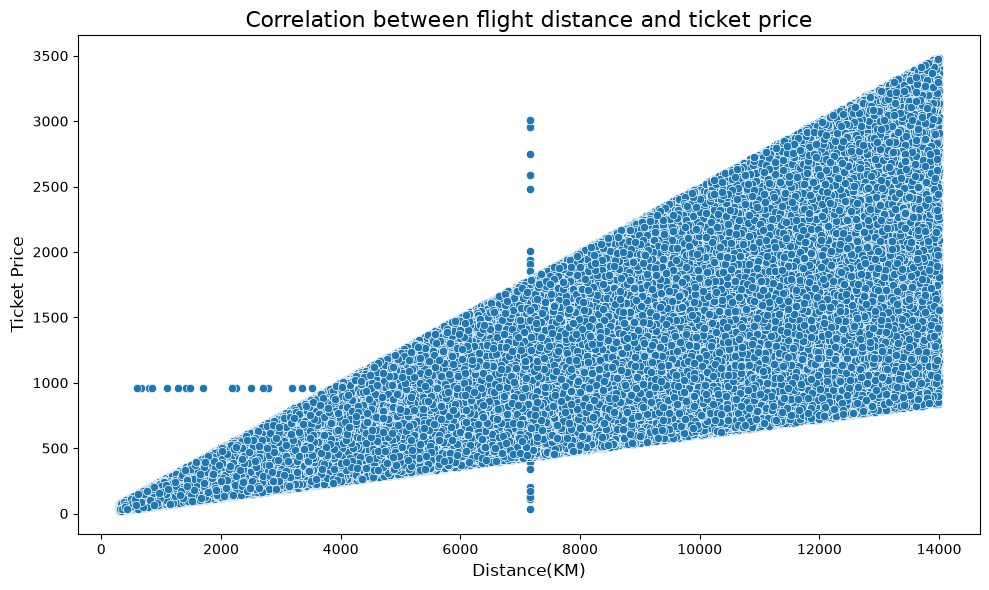

In [57]:

plt.figure(figsize=(10,6))
sns.scatterplot(x='distance_km', y='ticket_price', data=df)
plt.title('Correlation between flight distance and ticket price', fontsize=16)
plt.xlabel('Distance(KM)', fontsize=12)
plt.ylabel('Ticket Price', fontsize=12)
plt.tight_layout()
plt.show()

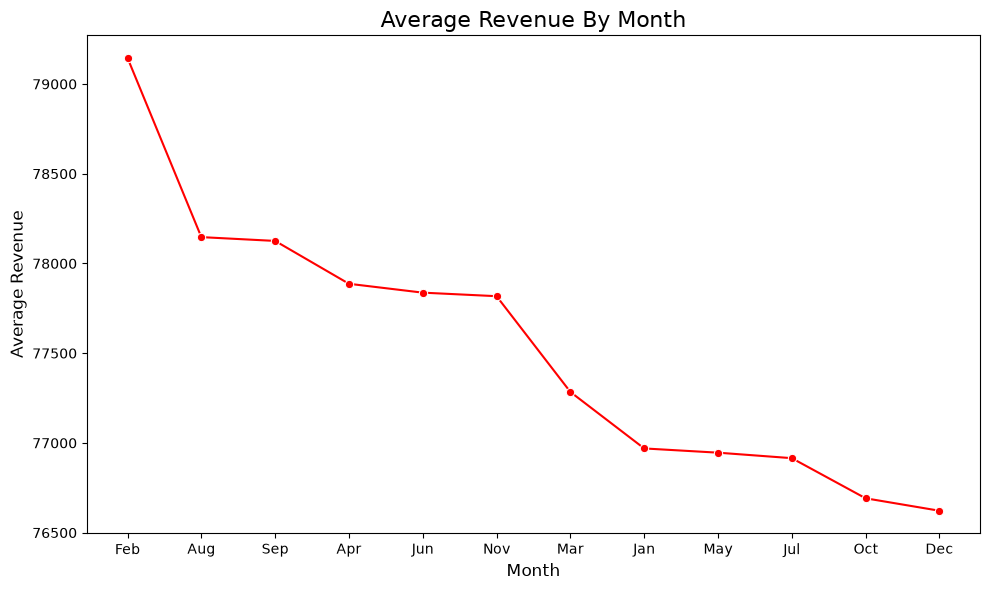

In [58]:
monthly_trend= df.groupby('flight_month')['total_revenue'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(x='flight_month', y='total_revenue', data=monthly_trend, marker='o', color='red')
plt.title('Average Revenue By Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Revenue', fontsize=12)
plt.tight_layout()
plt.show()

In [64]:
df.to_csv('cleaned_flights 2.csv', index=False)